<div class="alert alert-block alert-info">
<center><strong> Predict if a family is living in Urban/Rural area based on building type, roof type, and type of walls. </strong></center>
</div>

<hr/>
<center> A major course output (MCO) in completing 20% of final grade in Advanced Intelligent Systems (STINTSY) </center> 

Term 2 A.Y. 2025-2026
<br/>
**Group #2 CSINTSY Survivors (Section S18)**

| Member Name | Contributions |
| ----- | -----  |
| Chavez, Allen Visagar | text  |
| Llanes, Andre Gabriel De Ocampo  | text  |
| Rojo, Von Matthew De Guzman *(leader)* | text |
| Tan, Jeremy James Teves | text |

Professor: Antioquia, Arren Matthew Capuchino
<hr/>

In [1]:
## Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np # for importing datasets
import math
import pandas as pd
import seaborn as sns

%load_ext autoreload
%autoreload 2
from MCO_functions import *

# **[1]** Data Preparation
**Dataset Name:** Family Income and Expenditure Survey 2012 Vol 1
<br/>
**Accessed from:** [click this link](https://psada.psa.gov.ph/catalog/38/data-dictionary/F2?file_name=fies2012_v1)

In [2]:
csv_path = 'feis_dataset/FIES PUF 2012 Vol.1.CSV'
csvdict_path = 'feis_dataset/fies_2012_v1_metadata(dictionary)'
fies_original_df = pd.read_csv(csv_path)

fies_original_df

,W_REGN,W_OID,W_SHSN,W_HCN,URB,RSTR,PSU,BWEIGHT,RFACT,FSIZE,...,PC_QTY,OVEN_QTY,MOTOR_BANCA_QTY,MOTORCYCLE_QTY,POP_ADJ,PCINC,NATPC,NATDC,REGDC,REGPC
0,14,101001000,2,25,2,21100,415052,138.25,200.6576,3.0,...,01,01,,,0.946172,108417.00,9,8,8,9
1,14,101001000,3,43,2,21100,415052,138.25,200.6576,12.5,...,,01,,01,0.946172,30631.60,5,9,9,4
2,14,101001000,4,62,2,21100,415052,138.25,200.6576,2.0,...,,01,,,0.946172,86992.50,9,6,6,8
3,14,101001000,5,79,2,21100,415052,138.25,200.6576,4.0,...,,01,,,0.946172,43325.75,6,6,6,6
4,14,101001000,10,165,2,21100,415052,138.25,200.6576,5.0,...,,,,01,0.946172,37481.80,6,6,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40166,12,9804029001,18,568,1,22000,114062,271.25,963.2264,5.0,...,00,00,00,00,0.902863,30101.60,5,5,7,7
40167,12,9804035000,1,25,2,22000,414067,271.25,588.6253,9.0,...,00,01,00,00,0.902863,14368.89,1,5,7,3
40168,12,9804035000,2,51,2,22000,414067,271.25,588.6253,6.0,...,00,00,00,00,0.902863,19137.33,3,4,6,4
40169,12,9804035000,3,75,2,22000,414067,271.25,588.6253,5.0,...,00,01,00,00,0.902863,30985.00,5,6,7,7


# **[2]** Exploratory Data Analysis (EDA)
This phase allows exploration of datasets and check any anomalies present.
1. Basic Dataset Information
2. Urban and Rural Comparative Statistics

# **[2.1]** Basic Dataset Information
- column statistics
- number of null values
- number of duplicated entries

In [3]:
# summary for all columns
description = fies_original_df.describe().T
print(description.to_string())

                        count          mean           std           min           25%           50%           75%           max
W_REGN                40171.0  1.301989e+01  1.199555e+01  1.000000e+00  6.000000e+00  1.000000e+01  1.400000e+01  4.200000e+01
W_OID                 40171.0  4.210536e+09  2.285729e+09  1.010010e+08  2.239012e+09  4.112005e+09  6.210006e+09  9.804035e+09
W_SHSN                40171.0  9.633666e+00  6.198442e+00  1.000000e+00  4.000000e+00  9.000000e+00  1.400000e+01  3.000000e+01
W_HCN                 40171.0  1.563602e+03  2.977364e+03  1.000000e+00  9.500000e+01  2.040000e+02  3.930000e+02  8.026000e+03
URB                   40171.0  1.617311e+00  4.860494e-01  1.000000e+00  1.000000e+00  2.000000e+00  2.000000e+00  2.000000e+00
RSTR                  40171.0  2.154728e+04  3.520981e+03  2.475000e+03  2.110000e+04  2.210000e+04  2.320000e+04  2.900000e+04
PSU                   40171.0  2.581237e+05  1.121433e+05  1.000100e+05  1.163840e+05  2.162120e+05  3.1

In [4]:
# check if there is any null values or whitespaces
ws_or_na_df = fies_original_df.replace(r'^\s*$', pd.NA, regex=True)
ws_or_na_ctr = ws_or_na_df.isna().sum()
print("Whitespaces or null value counts: ")
print(ws_or_na_ctr.to_string())

Whitespaces or null value counts: 
W_REGN                      0
W_OID                       0
W_SHSN                      0
W_HCN                       0
URB                         0
RSTR                        0
PSU                         0
BWEIGHT                     0
RFACT                       0
FSIZE                       0
AGRI_SAL                    0
NONAGRI_SAL                 0
WAGES                       0
NETSHARE                    0
CASH_ABROAD                 0
CASH_DOMESTIC               0
RENTALS_REC                 0
INTEREST                    0
PENSION                     0
DIVIDENDS                   0
OTHER_SOURCE                0
NET_RECEIPT                 0
REGFT                       0
NET_CFG                     0
NET_LPR                     0
NET_FISH                    0
NET_FOR                     0
NET_RET                     0
NET_MFG                     0
NET_COM                     0
NET_TRANS                   0
NET_MIN                     0
NET_C

In [5]:
# check if there are any duplicates
dupes = fies_original_df.duplicated().sum()

if (dupes <= 0):
  print('There are no duplicates')
else:
  print('There are', dupes, 'duplicates')

There are no duplicates


# **[2.2]** Urban and Rural Comparative Statistics
- income and expenditure distribution
- regional distribution
- household composition

 ### **1.) Income and Expenditure Distribution** 

In [6]:
columns = ws_or_na_df.columns
T_columns = [col for col in columns if col.startswith("T_")] # categories
NET_columns = [col for col in columns if col.startswith("NET_")] # categories
NET_columns.extend(["REGFT","EAINC","TOINC"])

rural_df =  ws_or_na_df[ws_or_na_df["URB"] == 2]
urban_df = ws_or_na_df[ws_or_na_df["URB"] == 1]

rural_T_df = rural_df[T_columns]
urban_T_df = urban_df[T_columns]

rural_T_mean_sr = rural_T_df.mean()
urban_T_mean_sr = urban_T_df.mean()


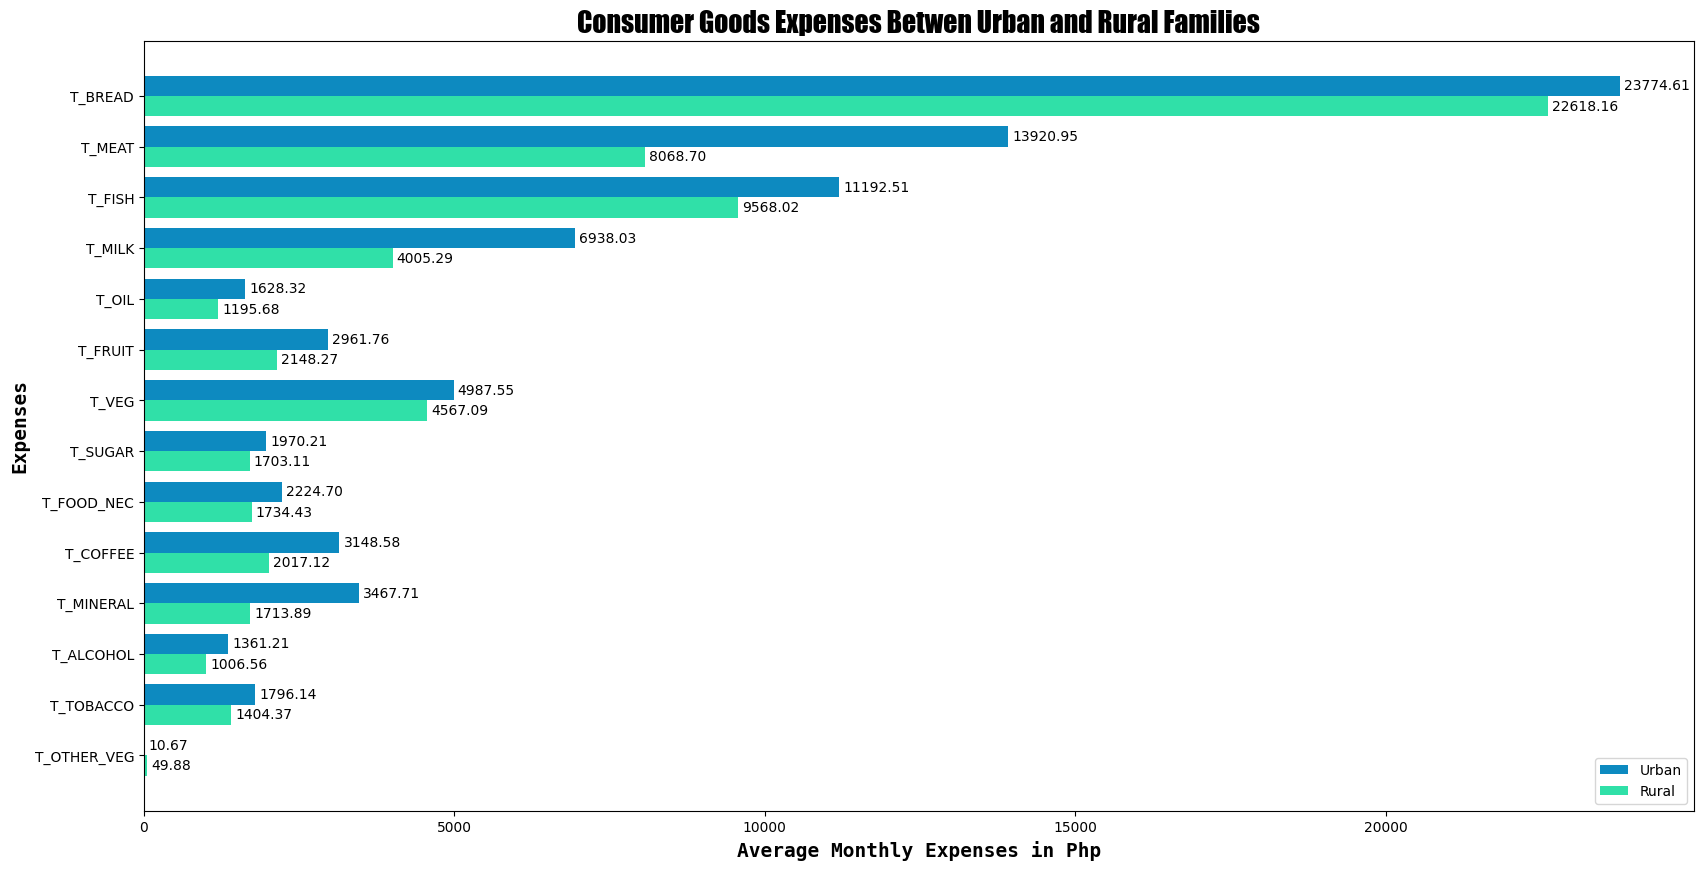

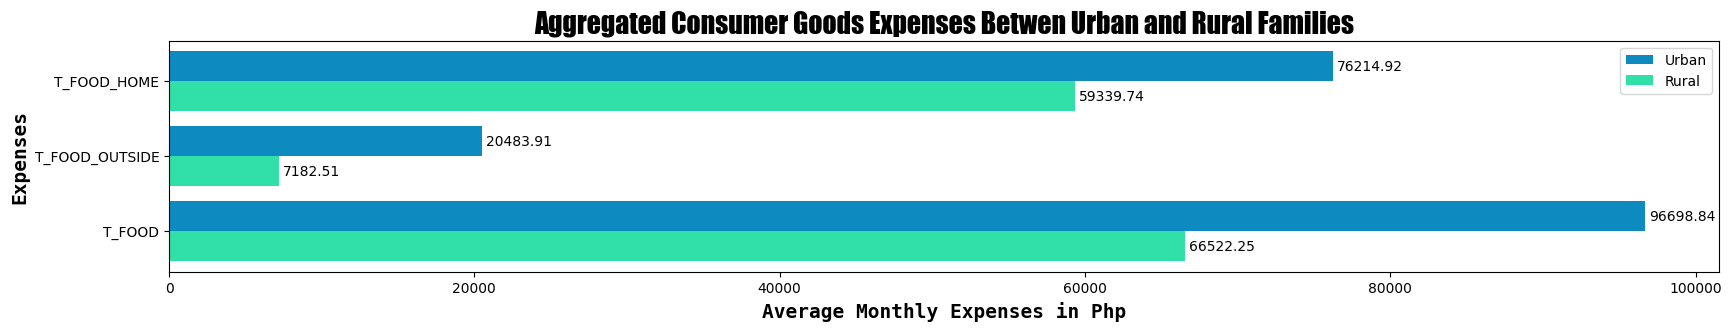

In [7]:
categories = ["T_BREAD","T_MEAT","T_FISH","T_MILK","T_OIL","T_FRUIT","T_VEG","T_SUGAR","T_FOOD_NEC","T_COFFEE","T_MINERAL","T_ALCOHOL","T_TOBACCO","T_OTHER_VEG"]
n = len(categories)
urban = urban_T_mean_sr[categories]
rural = rural_T_mean_sr[categories]
title = "Consumer Goods Expenses Betwen Urban and Rural Families"
compareChart(n, categories, 20, 10, urban, rural, title)

categories = ["T_FOOD_HOME", "T_FOOD_OUTSIDE", "T_FOOD"]
n = len(categories)
urban = urban_T_mean_sr[categories]
rural = rural_T_mean_sr[categories]
title = "Aggregated Consumer Goods Expenses Betwen Urban and Rural Families"
compareChart(n, categories, 20, 3, urban, rural, title)

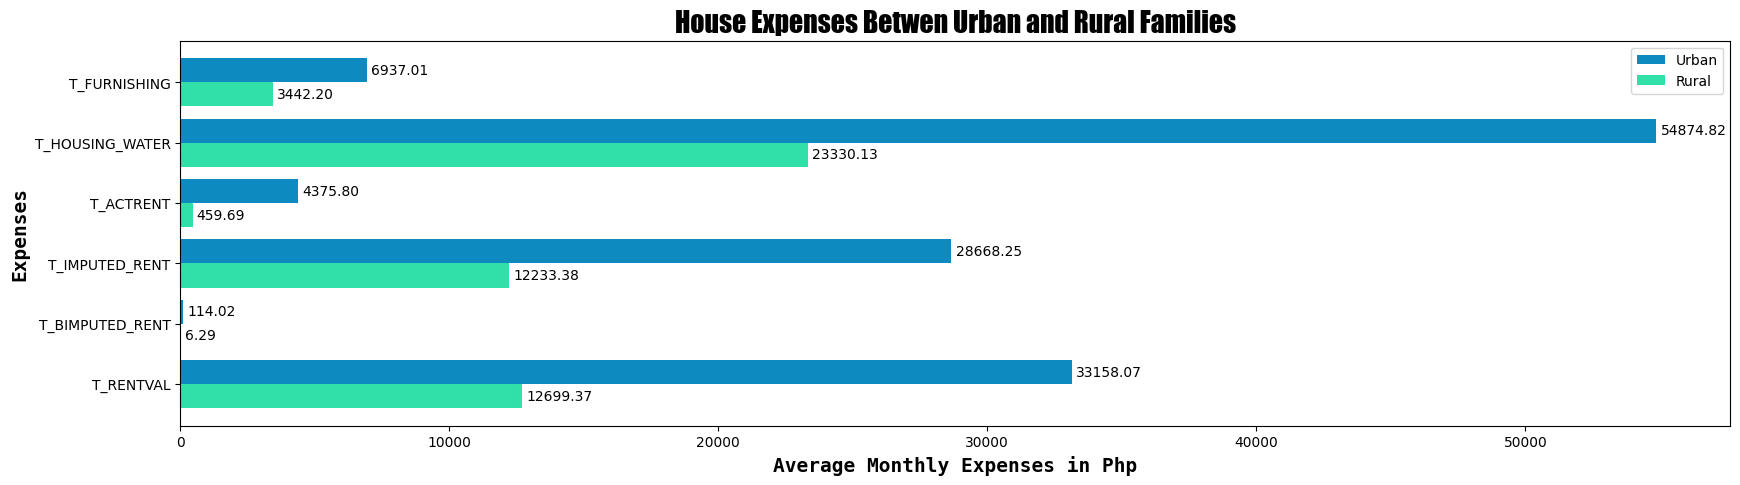

In [8]:
categories = ["T_FURNISHING", "T_HOUSING_WATER", "T_ACTRENT", "T_IMPUTED_RENT", "T_BIMPUTED_RENT","T_RENTVAL"]
n = len(categories)
urban = urban_T_mean_sr[categories]
rural = rural_T_mean_sr[categories]
title = "House Expenses Betwen Urban and Rural Families"
compareChart(n, categories, 20, 5, urban, rural, title)


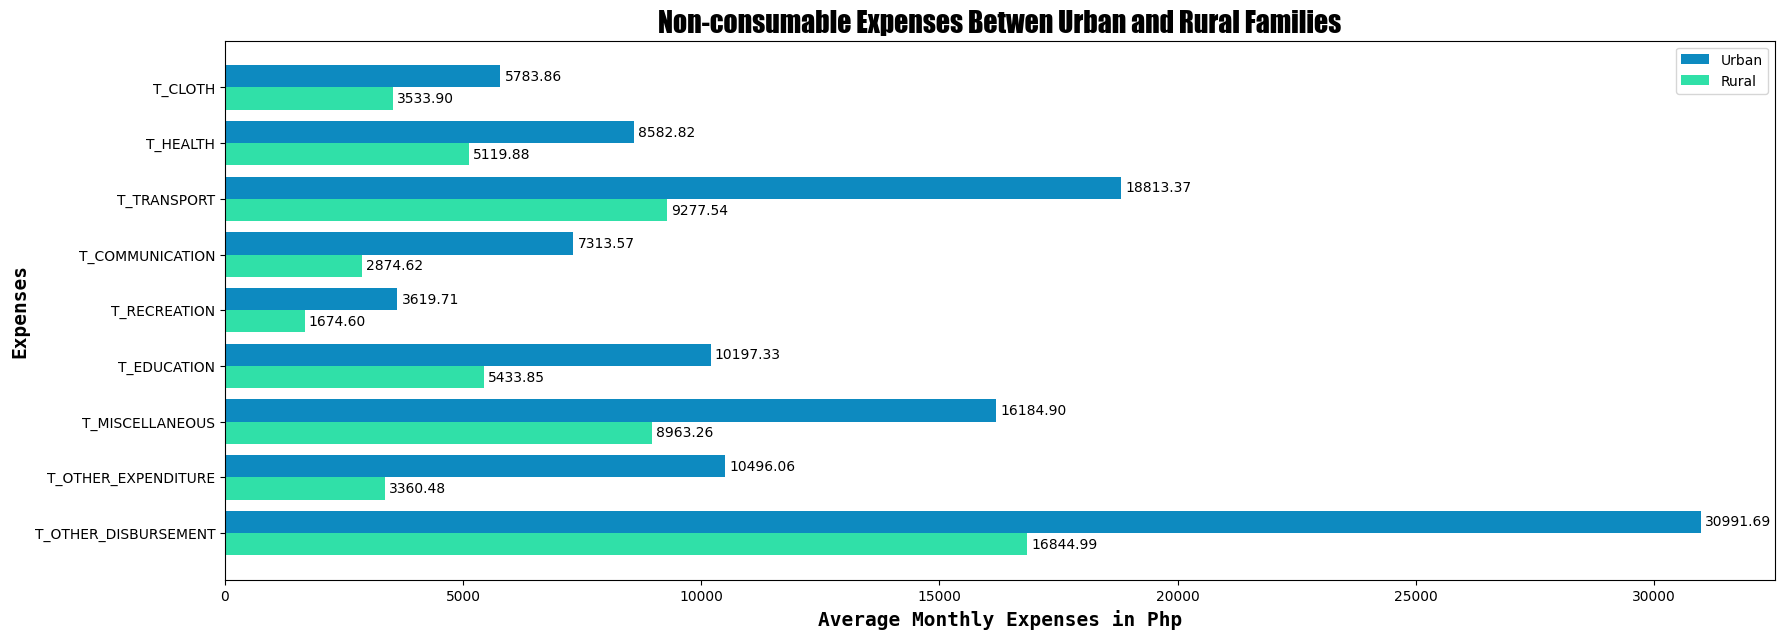

In [9]:
categories = ["T_CLOTH", "T_HEALTH", "T_TRANSPORT", "T_COMMUNICATION", "T_RECREATION", "T_EDUCATION", "T_MISCELLANEOUS", "T_OTHER_EXPENDITURE", "T_OTHER_DISBURSEMENT"]
n = len(categories)
urban = urban_T_mean_sr[categories]
rural = rural_T_mean_sr[categories]
title = "Non-consumable Expenses Betwen Urban and Rural Families"
compareChart(n, categories, 20, 7, urban, rural, title)

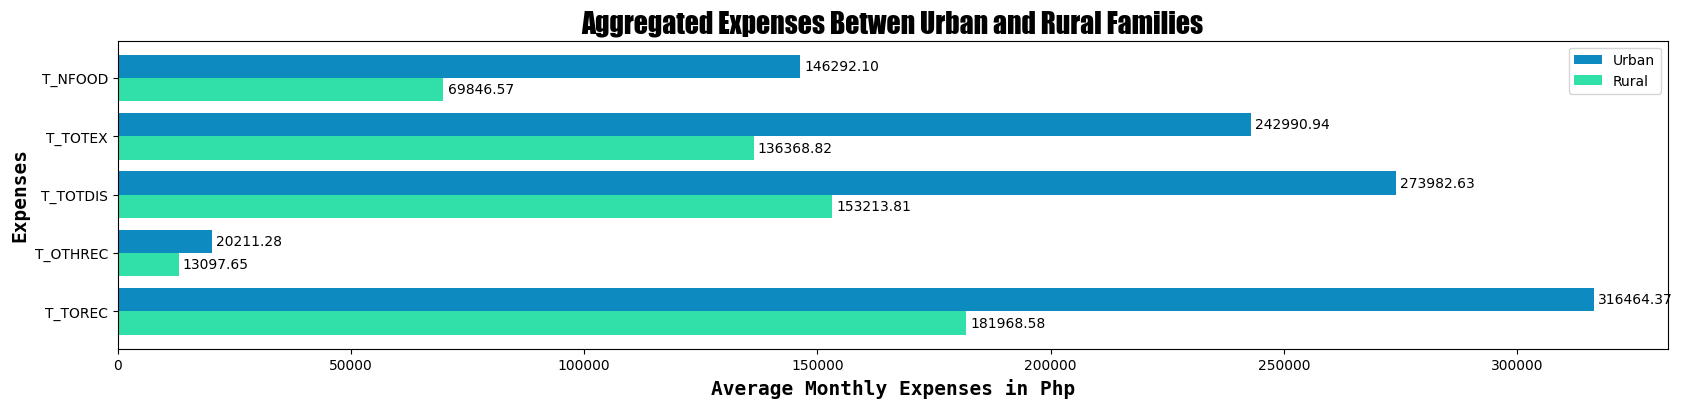

In [10]:
categories = ["T_NFOOD", "T_TOTEX", "T_TOTDIS", "T_OTHREC", "T_TOREC"]
n = len(categories)
urban = urban_T_mean_sr[categories]
rural = rural_T_mean_sr[categories]
title = "Aggregated Expenses Betwen Urban and Rural Families"
compareChart(n, categories, 20, 4, urban, rural, title)

 ### **2.) Regional Distribution** 

In [11]:

# ── Label mappings ────────────────────────────────────────────────────────────
REGION_LABELS = {
    1:  "Region I\n(Ilocos)",        2:  "Region II\n(Cagayan Valley)",
    3:  "Region III\n(C. Luzon)",    5:  "Region V\n(Bicol)",
    6:  "Region VI\n(W. Visayas)",   7:  "Region VII\n(C. Visayas)",
    8:  "Region VIII\n(E. Visayas)", 9:  "Region IX\n(Zamboanga)",
    10: "Region X\n(N. Mindanao)",   11: "Region XI\n(Davao)",
    12: "Region XII\n(SOCCSKSARGEN)",13: "NCR",
    14: "CAR",                        15: "ARMM",
    16: "CARAGA",                     41: "Region IVA\n(CALABARZON)",
    42: "Region IVB\n(MIMAROPA)",
}
BLDG_LABELS  = {1:"Single House", 2:"Duplex", 3:"Multi-unit", 4:"Commercial/Industrial", 5:"Makeshift", 6:"Other"}
ROOF_LABELS  = {1:"Strong", 2:"Light", 3:"Salvaged/Makeshift", 4:"Mixed→Strong", 5:"Mixed→Light", 6:"Mixed→Salvaged", 7:"N/A"}
WALLS_LABELS = {1:"Strong", 2:"Light", 3:"Salvaged/Makeshift", 4:"Mixed→Strong", 5:"Mixed→Light", 6:"Mixed→Salvaged", 7:"N/A"}
TOILET_LABELS= {0:"None", 1:"Water-sealed (own)", 2:"Water-sealed (shared)", 3:"WS Other (own)", 4:"WS Other (shared)", 5:"Closed Pit", 6:"Open Pit", 7:"Others"}
ELECTRIC_LABELS = {1:"Yes", 2:"No"}
WATER_LABELS = {
    1:"Comm. Faucet (own)", 2:"Comm. Faucet (shared)", 3:"Deep Well (own)",
    4:"Deep Well (shared)", 5:"Shallow Well", 6:"Dug Well",
    7:"Protected Spring", 8:"Unprotected Spring", 9:"Lake/River/Rain",
    10:"Peddler", 11:"Bottled", 12:"Others"
}

urban_c, rural_c = "#0d8ac0", "#30e0a8"

# Apply readable labels to a working copy
ws_or_na_df_labeled = ws_or_na_df.copy()
ws_or_na_df_labeled["URB_LABEL"]   = ws_or_na_df_labeled["URB"].map({1:"Urban", 2:"Rural"})
ws_or_na_df_labeled["REGION_LABEL"]= ws_or_na_df_labeled["W_REGN"].map(REGION_LABELS)

print("Label mappings ready.")


Label mappings ready.


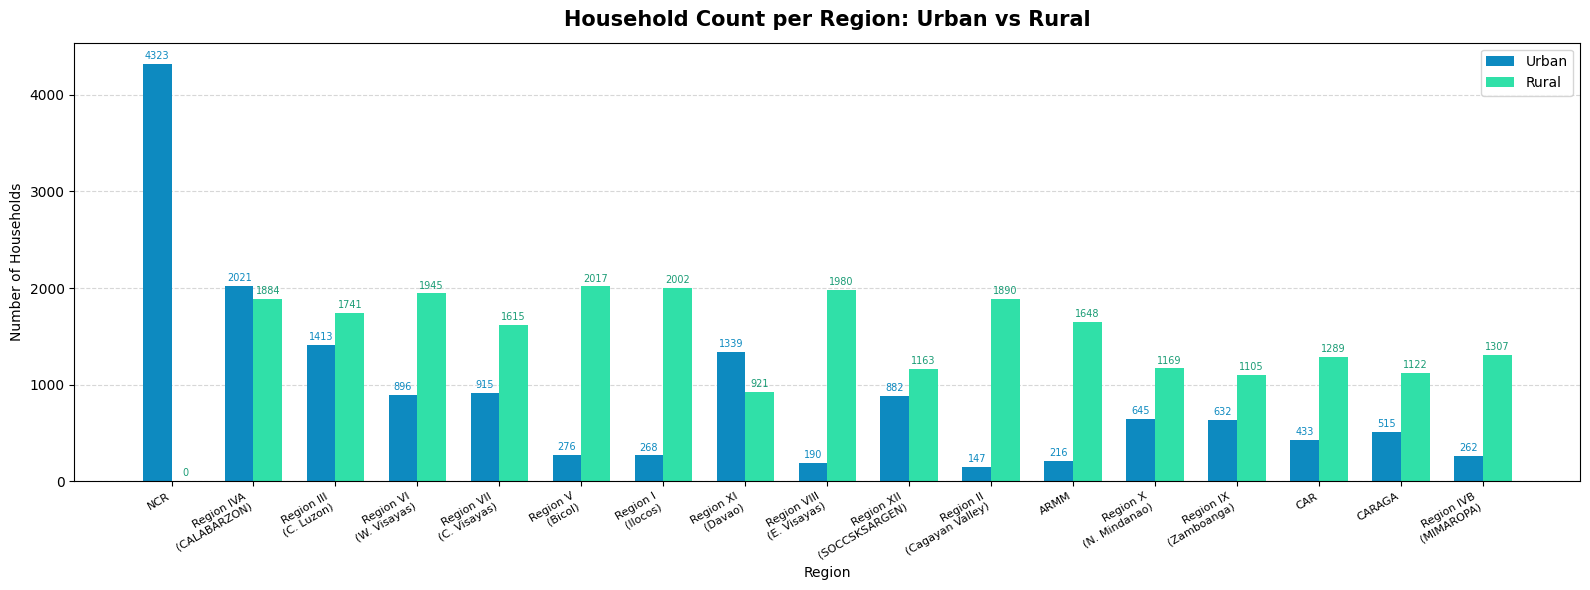

In [12]:

# ── Regional counts: Urban vs Rural ─────────────────────────────────────────
region_urb = (
    ws_or_na_df_labeled
    .groupby(["REGION_LABEL", "URB_LABEL"])
    .size()
    .unstack(fill_value=0)
)
# Ensure both columns exist
for col in ["Urban", "Rural"]:
    if col not in region_urb.columns:
        region_urb[col] = 0

region_urb["Total"] = region_urb["Urban"] + region_urb["Rural"]
region_urb = region_urb.sort_values("Total", ascending=False)

# ── Plot 1: Grouped bar — raw counts ────────────────────────────────────────
regions = region_urb.index.tolist()
x       = np.arange(len(regions))
bar_w   = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
b_u = ax.bar(x - bar_w/2, region_urb["Urban"], bar_w, label="Urban", color=urban_c)
b_r = ax.bar(x + bar_w/2, region_urb["Rural"],  bar_w, label="Rural",  color=rural_c)

for bar in b_u:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=7, color=urban_c)
for bar in b_r:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=7, color="#1a9c75")

ax.set_title("Household Count per Region: Urban vs Rural", fontsize=15, fontweight="bold", pad=12)
ax.set_xticks(x); ax.set_xticklabels(regions, fontsize=8, rotation=30, ha="right")
ax.set_xlabel("Region"); ax.set_ylabel("Number of Households")
ax.yaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ax.legend()
plt.tight_layout(); plt.show()


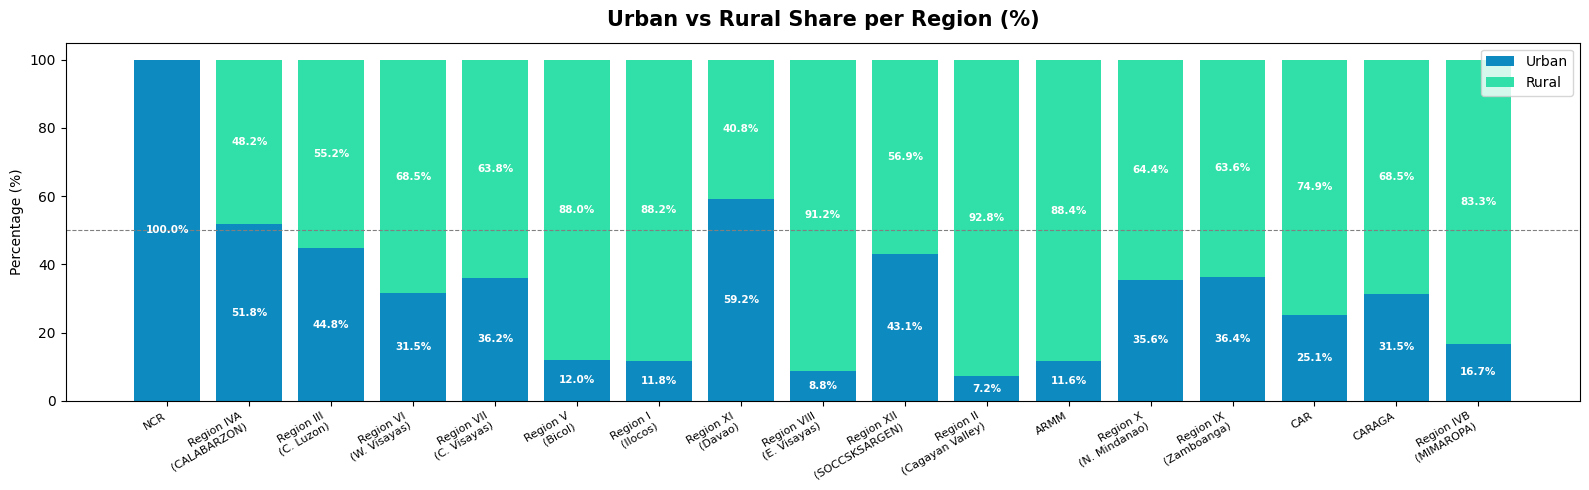


Region                             Urban   Rural   Total  %Urban  %Rural
────────────────────────────────────────────────────────────────────
NCR                                 4323       0    4323   100.0     0.0
Region IVA (CALABARZON)             2021    1884    3905    51.8    48.2
Region III (C. Luzon)               1413    1741    3154    44.8    55.2
Region VI (W. Visayas)               896    1945    2841    31.5    68.5
Region VII (C. Visayas)              915    1615    2530    36.2    63.8
Region V (Bicol)                     276    2017    2293    12.0    88.0
Region I (Ilocos)                    268    2002    2270    11.8    88.2
Region XI (Davao)                   1339     921    2260    59.2    40.8
Region VIII (E. Visayas)             190    1980    2170     8.8    91.2
Region XII (SOCCSKSARGEN)            882    1163    2045    43.1    56.9
Region II (Cagayan Valley)           147    1890    2037     7.2    92.8
ARMM                                 216    1648    18

In [13]:

# Plot 2: Stacked 100% bar — Urban/Rural proportion per region 
region_pct = region_urb[["Urban","Rural"]].div(region_urb["Total"], axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(regions, region_pct["Urban"], label="Urban", color=urban_c)
ax.bar(regions, region_pct["Rural"], bottom=region_pct["Urban"], label="Rural", color=rural_c)

for i, r in enumerate(regions):
    u, ru = region_pct.loc[r,"Urban"], region_pct.loc[r,"Rural"]
    if u  >= 6: ax.text(i, u/2,    f"{u:.1f}%",  ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")
    if ru >= 6: ax.text(i, u+ru/2, f"{ru:.1f}%", ha="center", va="center", fontsize=7.5, color="white", fontweight="bold")

ax.axhline(50, linestyle="--", color="gray", linewidth=0.8)
ax.set_title("Urban vs Rural Share per Region (%)", fontsize=15, fontweight="bold", pad=12)
ax.set_xticks(range(len(regions))); ax.set_xticklabels(regions, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("Percentage (%)"); ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout(); plt.show()

# Summary table
stats = region_urb.copy()
stats["% Urban"] = (stats["Urban"] / stats["Total"] * 100).round(1)
stats["% Rural"] = (stats["Rural"] / stats["Total"] * 100).round(1)
print(f"\n{'Region':<32} {'Urban':>7} {'Rural':>7} {'Total':>7} {'%Urban':>7} {'%Rural':>7}")
print("─" * 68)
for region, row in stats.iterrows():
    print(f"{region.replace(chr(10),' '):<32} {int(row.Urban):>7} {int(row.Rural):>7} {int(row.Total):>7} {row['% Urban']:>7.1f} {row['% Rural']:>7.1f}")
print("─" * 68)
tot = stats[["Urban","Rural","Total"]].sum()
print(f"{'TOTAL':<32} {int(tot.Urban):>7} {int(tot.Rural):>7} {int(tot.Total):>7} {tot.Urban/tot.Total*100:>7.1f} {tot.Rural/tot.Total*100:>7.1f}")


#### Structural Feature Distributions: Urban vs Rural
How building type, roof material, and wall material differ between urban and rural households.

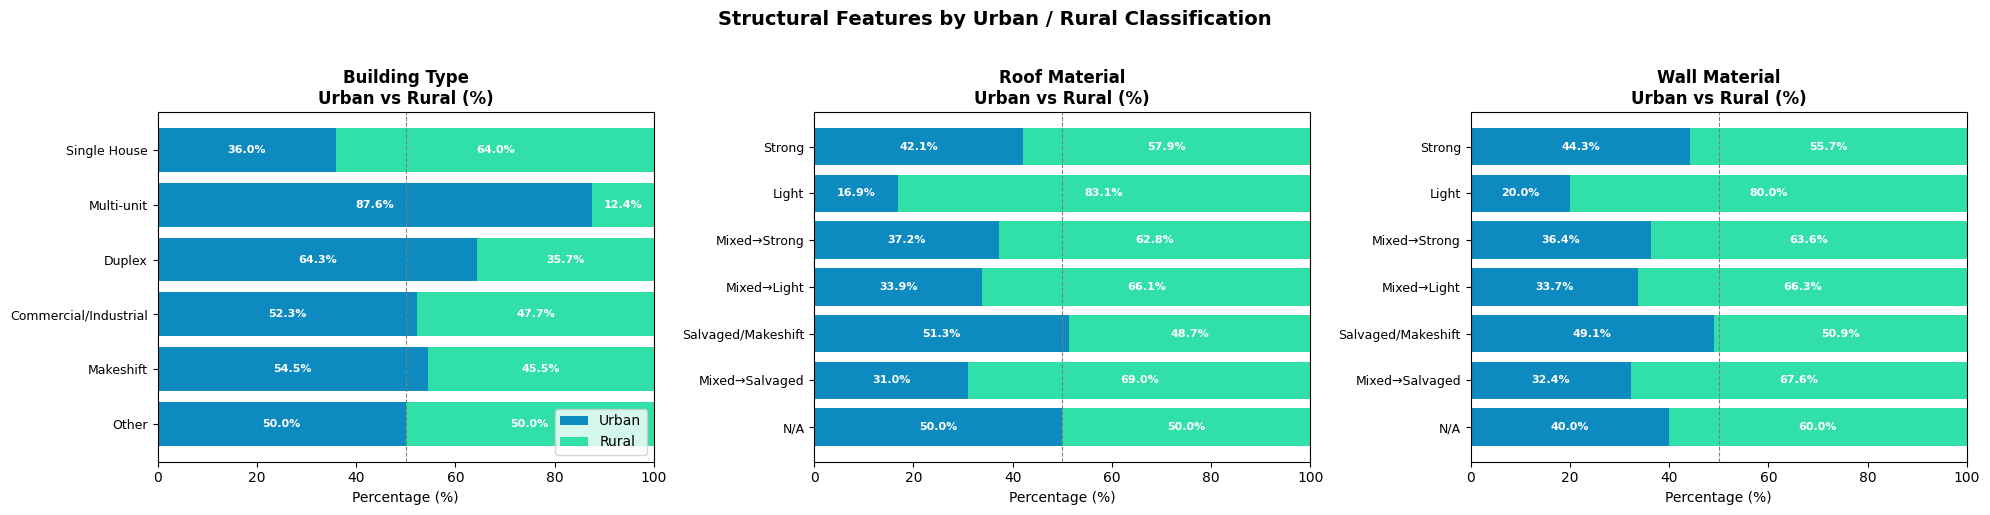

In [14]:

def stacked_pct_chart(ax, df, col, label_map, title, urb_col="URB_LABEL"):
    grouped = (
        df.groupby([col, urb_col])
        .size()
        .unstack(fill_value=0)
    )
    for c in ["Urban","Rural"]:
        if c not in grouped: grouped[c] = 0
    grouped["Total"] = grouped["Urban"] + grouped["Rural"]
    grouped = grouped.sort_values("Total", ascending=True)      # most common at top
    grouped["Urban%"] = grouped["Urban"] / grouped["Total"] * 100
    grouped["Rural%"] = grouped["Rural"] / grouped["Total"] * 100

    labels = [label_map.get(idx, str(idx)) for idx in grouped.index]
    y = np.arange(len(labels))

    ax.barh(y, grouped["Urban%"], color=urban_c, label="Urban")
    ax.barh(y, grouped["Rural%"], left=grouped["Urban%"], color=rural_c, label="Rural")

    for i in range(len(y)):
        u, r = grouped["Urban%"].iloc[i], grouped["Rural%"].iloc[i]
        if u >= 8:  ax.text(u/2,          i, f"{u:.1f}%", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        if r >= 8:  ax.text(u + r/2,      i, f"{r:.1f}%", ha="center", va="center", fontsize=8, color="white", fontweight="bold")

    ax.axvline(50, color="gray", linestyle="--", linewidth=0.8)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(0, 100); ax.set_xlabel("Percentage (%)")
    ax.set_title(title, fontsize=12, fontweight="bold")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

stacked_pct_chart(axes[0], ws_or_na_df_labeled, "BLDG_TYPE", BLDG_LABELS,
                  "Building Type\nUrban vs Rural (%)")
stacked_pct_chart(axes[1], ws_or_na_df_labeled, "ROOF",      ROOF_LABELS,
                  "Roof Material\nUrban vs Rural (%)")
stacked_pct_chart(axes[2], ws_or_na_df_labeled, "WALLS",     WALLS_LABELS,
                  "Wall Material\nUrban vs Rural (%)")

axes[0].legend(loc="lower right"); 
fig.suptitle("Structural Features by Urban / Rural Classification",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


#### Amenity Distributions: Urban vs Rural
Toilet type, electricity access, and water source.

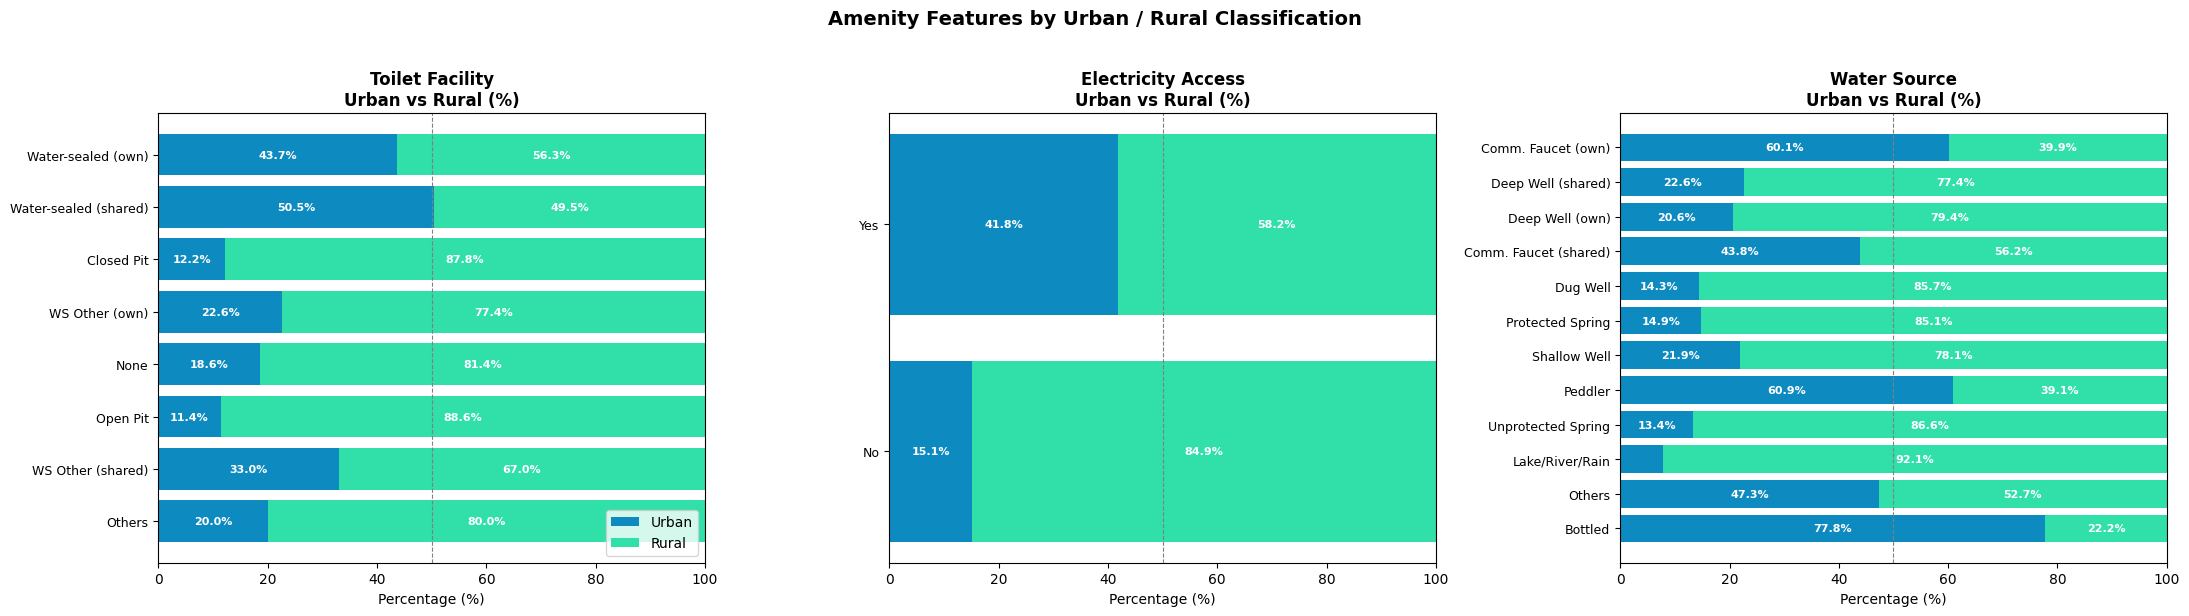

In [15]:

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

stacked_pct_chart(axes[0], ws_or_na_df_labeled, "TOILET",   TOILET_LABELS,
                  "Toilet Facility\nUrban vs Rural (%)")
stacked_pct_chart(axes[1], ws_or_na_df_labeled, "ELECTRIC", ELECTRIC_LABELS,
                  "Electricity Access\nUrban vs Rural (%)")
stacked_pct_chart(axes[2], ws_or_na_df_labeled, "WATER",    WATER_LABELS,
                  "Water Source\nUrban vs Rural (%)")

axes[0].legend(loc="lower right")
fig.suptitle("Amenity Features by Urban / Rural Classification",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


#### Appliance & Vehicle Ownership: Urban vs Rural
Average ownership counts per household for appliances and vehicles.

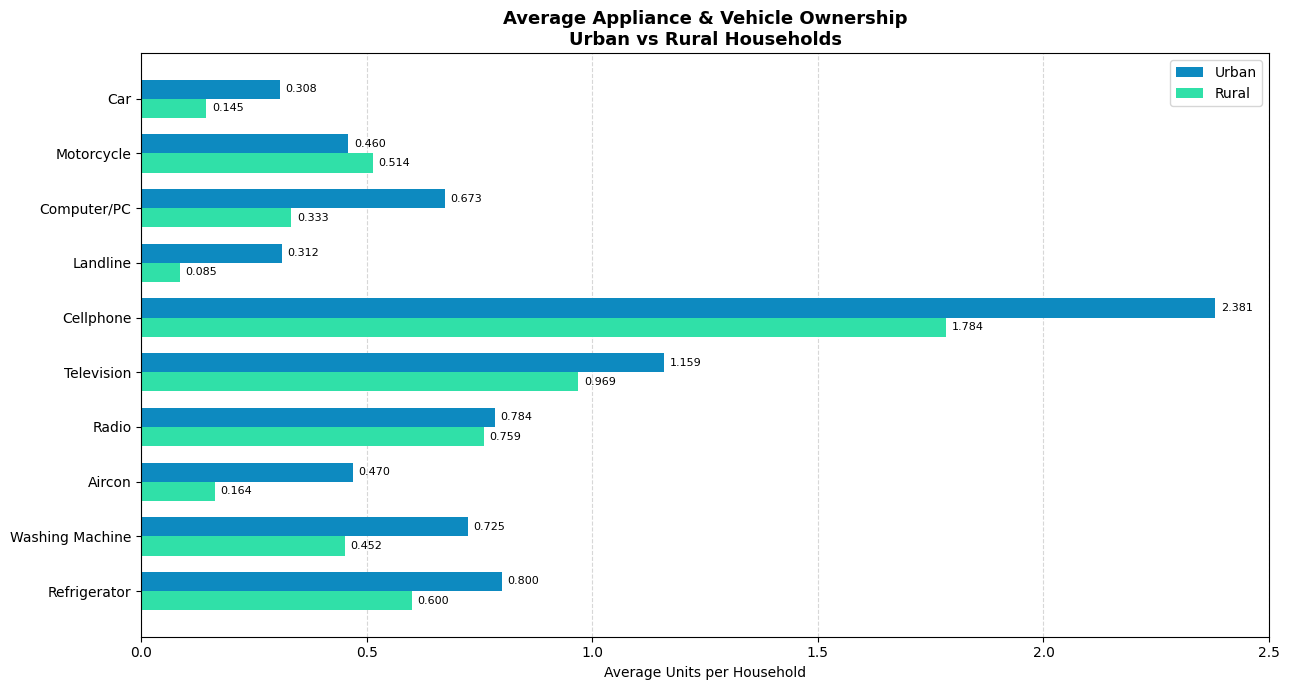

In [16]:

appliance_cols = {
    "CAR_QTY":        "Car",
    "MOTORCYCLE_QTY": "Motorcycle",
    "PC_QTY":         "Computer/PC",
    "LANDLINE_QTY":   "Landline",
    "CELLPHONE_QTY":  "Cellphone",
    "TV_QTY":         "Television",
    "RADIO_QTY":      "Radio",
    "AIRCON_QTY":     "Aircon",
    "WASH_QTY":       "Washing Machine",
    "REF_QTY":        "Refrigerator",
}

app_df = ws_or_na_df_labeled[list(appliance_cols.keys()) + ["URB_LABEL"]].copy()
for col in appliance_cols:
    app_df[col] = pd.to_numeric(app_df[col], errors="coerce")

app_mean = (
    app_df
    .groupby("URB_LABEL")[list(appliance_cols.keys())]
    .mean()
    .rename(columns=appliance_cols)
    .T
)

n = len(app_mean)
y = np.arange(n)
bar_h = 0.35

fig, ax = plt.subplots(figsize=(13, 7))
b_u = ax.barh(y - bar_h/2, app_mean["Urban"], height=bar_h, label="Urban", color=urban_c)
b_r = ax.barh(y + bar_h/2, app_mean["Rural"],  height=bar_h, label="Rural",  color=rural_c)

ax.bar_label(b_u, padding=4, fmt="{:.3f}", fontsize=8)
ax.bar_label(b_r, padding=4, fmt="{:.3f}", fontsize=8)

ax.set_yticks(y); ax.set_yticklabels(app_mean.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Average Units per Household")
ax.set_title("Average Appliance & Vehicle Ownership\nUrban vs Rural Households",
             fontsize=13, fontweight="bold")
ax.xaxis.grid(True, linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ax.legend()
plt.tight_layout(); plt.show()


 ### **3.) Household Composition** 

Household Physical Composition (BLDG_TYPE, ROOF, WALLS, TOILET, ELECTRIC, WATER)

In [17]:
physical_features = ['BLDG_TYPE', 'ROOF', 'WALLS', 'TOILET', 'ELECTRIC', 'WATER']

# A. Statistical summaries
print("Physical Housing Composition Summaries")
for col in physical_features:
    if col in ws_or_na_df.columns:
        print(f"\nValue Counts for {col}:")
        print(ws_or_na_df[col].value_counts(normalize=True) * 100)

Physical Housing Composition Summaries

Value Counts for BLDG_TYPE:
BLDG_TYPE
1    94.503498
3     2.957357
2     2.392273
4     0.109532
5     0.027383
6     0.009957
Name: proportion, dtype: float64

Value Counts for ROOF:
ROOF
1    78.867840
2    13.698937
4     4.889099
5     1.924274
3     0.465510
6     0.144383
7     0.009957
Name: proportion, dtype: float64

Value Counts for WALLS:
WALLS
1    66.172114
2    20.407757
4     8.543477
5     3.778845
3     0.831446
6     0.253915
7     0.012447
Name: proportion, dtype: float64

Value Counts for TOILET:
TOILET
1    67.797665
2     8.466307
5     6.118842
3     5.588609
0     4.799482
6     3.689229
4     2.397252
7     1.142615
Name: proportion, dtype: float64

Value Counts for ELECTRIC:
ELECTRIC
1    86.843743
2    13.156257
Name: proportion, dtype: float64

Value Counts for WATER:
WATER
1     37.868114
4     16.118593
3     11.963855
2     11.030345
6      8.643051
7      5.060865
5      3.519952
10     2.068656
8      1.824699
9 

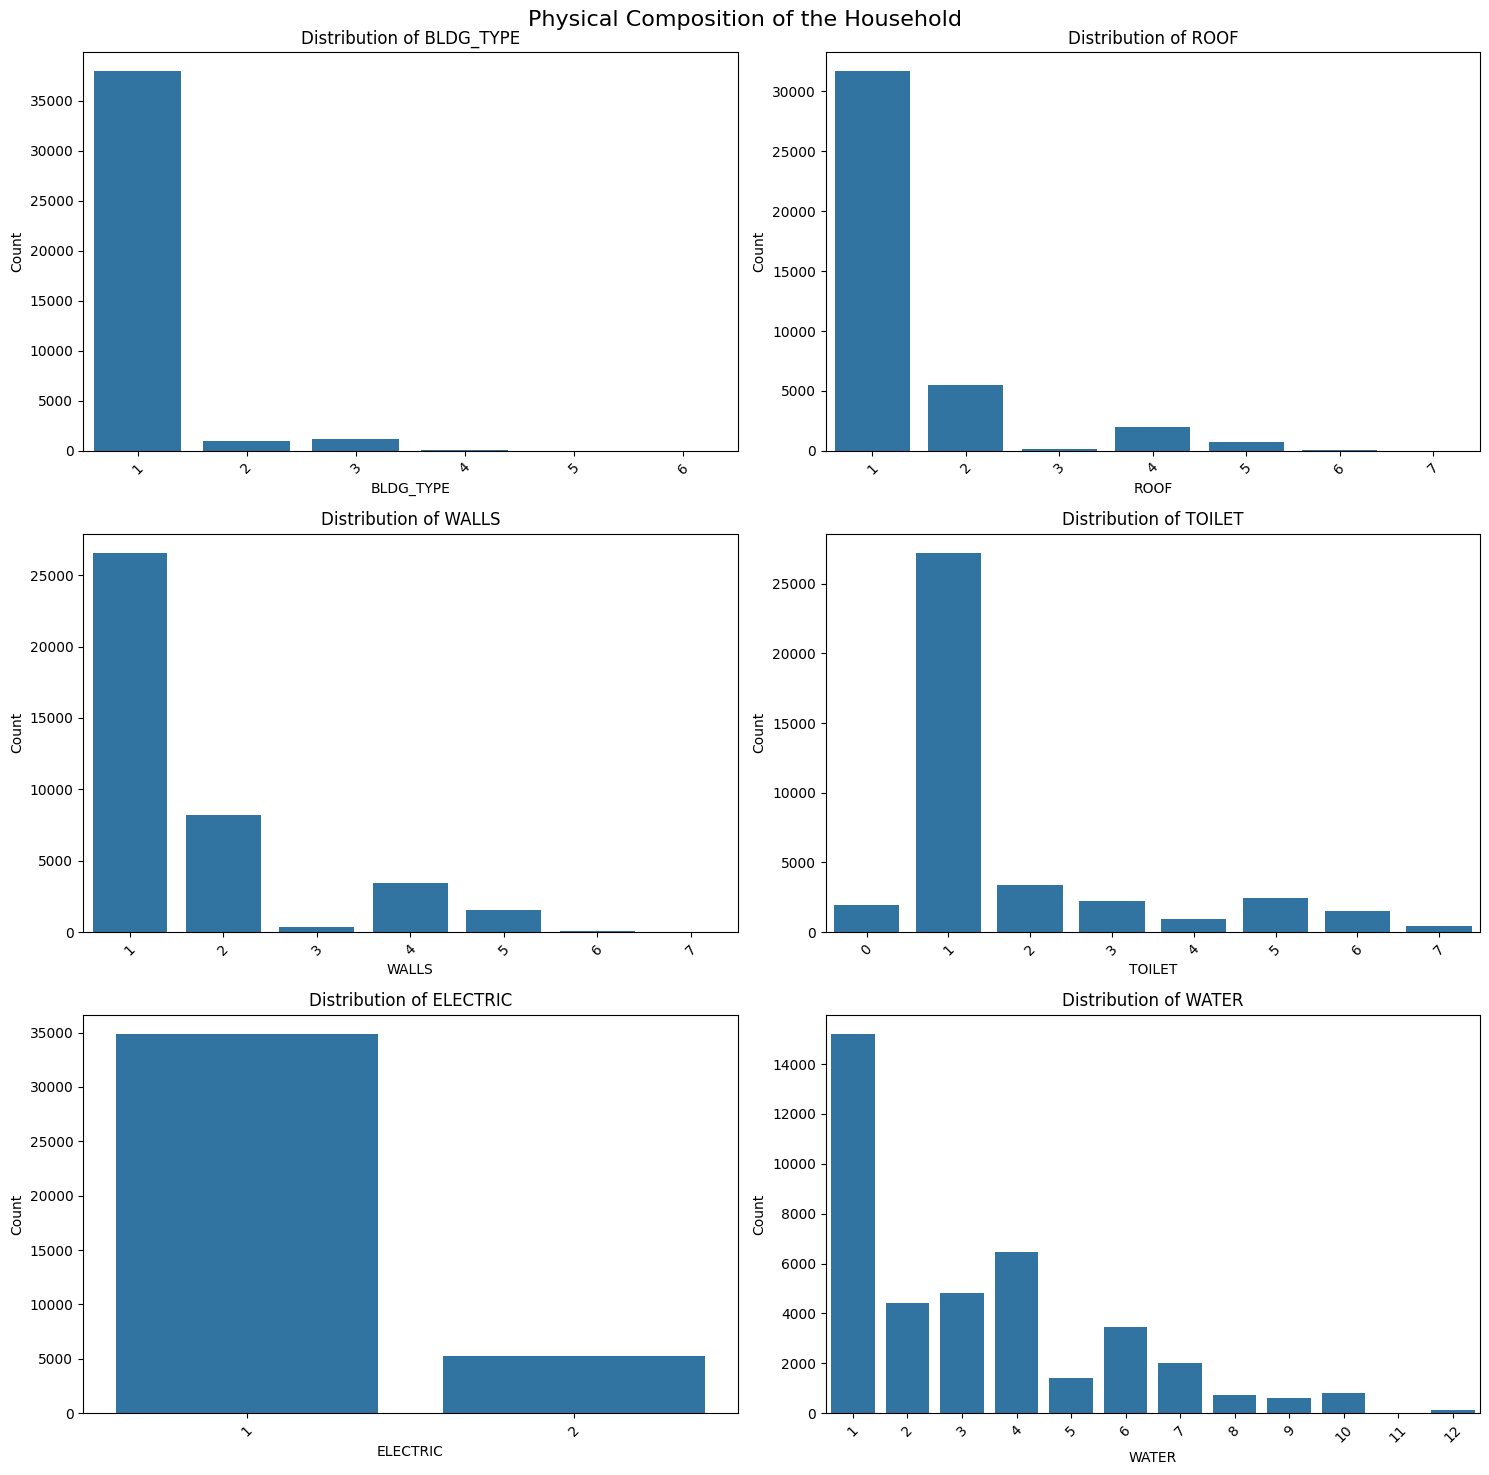

In [18]:
# B. Visualizing Physical Housing Composition (Categorical)
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Physical Composition of the Household', fontsize=16)

for i, col in enumerate(physical_features):
    if col in ws_or_na_df.columns:
        ax = axes[i//2, i%2]
        sns.countplot(data=ws_or_na_df, x=col, ax=ax)
        ax.set_title(f'Distribution of {col}')
        ax.tick_params(axis='x', rotation=45) 
        ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

Household Asset Composition

In [19]:
asset_features = ['CAR_QTY', 'MOTORCYCLE_QTY', 'PC_QTY', 'LANDLINE_QTY', 'CELLPHONE_QTY', 
                  'TV_QTY', 'RADIO_QTY', 'AIRCON_QTY', 'WASH_QTY', 'REF_QTY']

# A. Statistical summaries
print("\nHousehold Asset Composition Summaries")
display(ws_or_na_df[asset_features].describe())


Household Asset Composition Summaries


,CAR_QTY,MOTORCYCLE_QTY,PC_QTY,LANDLINE_QTY,CELLPHONE_QTY,TV_QTY,RADIO_QTY,AIRCON_QTY,WASH_QTY,REF_QTY
count,14014,17043,16741,14038,33746,32359,24118,14541,20065,22390
unique,7,8,7,6,15,8,6,8,7,6
top,00,00,00,00,01,01,01,00,01,01
freq,11615,9790,10395,11703,11921,25769,17366,11238,11284,14003


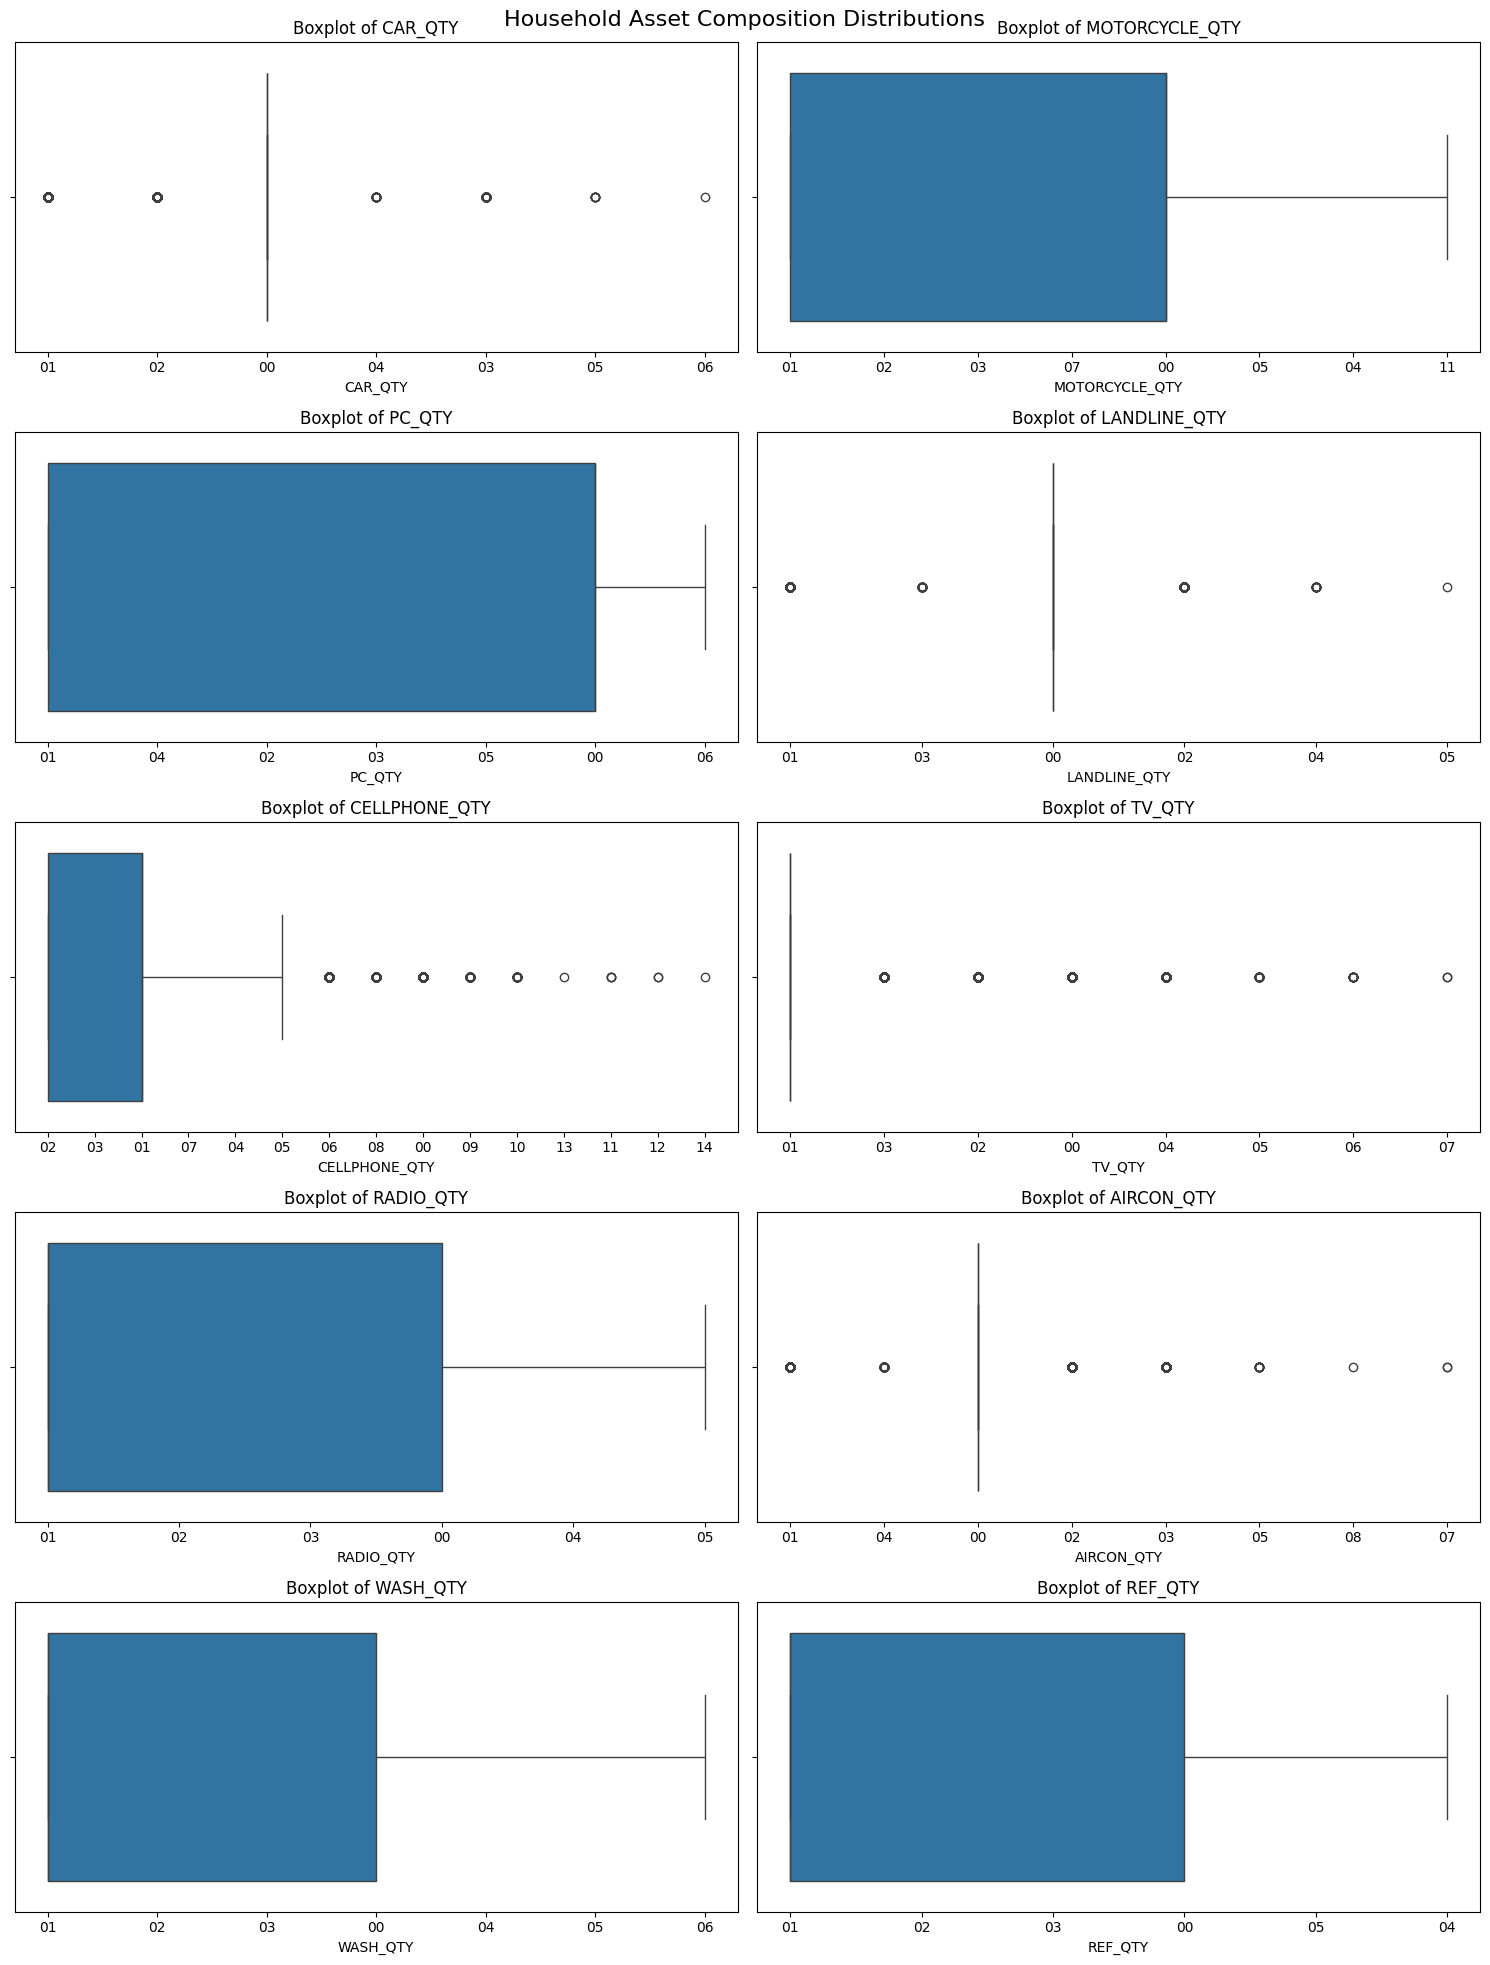

In [20]:
# B. Visualizing Asset/Appliance Quantities (Numerical)
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
fig.suptitle('Household Asset Composition Distributions', fontsize=16)

for i, col in enumerate(asset_features):
    if col in ws_or_na_df.columns:
        ax = axes[i//2, i%2]

        # Using a boxplot to easily spot outliers
        sns.boxplot(data=ws_or_na_df, x=col, ax=ax)
        ax.set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

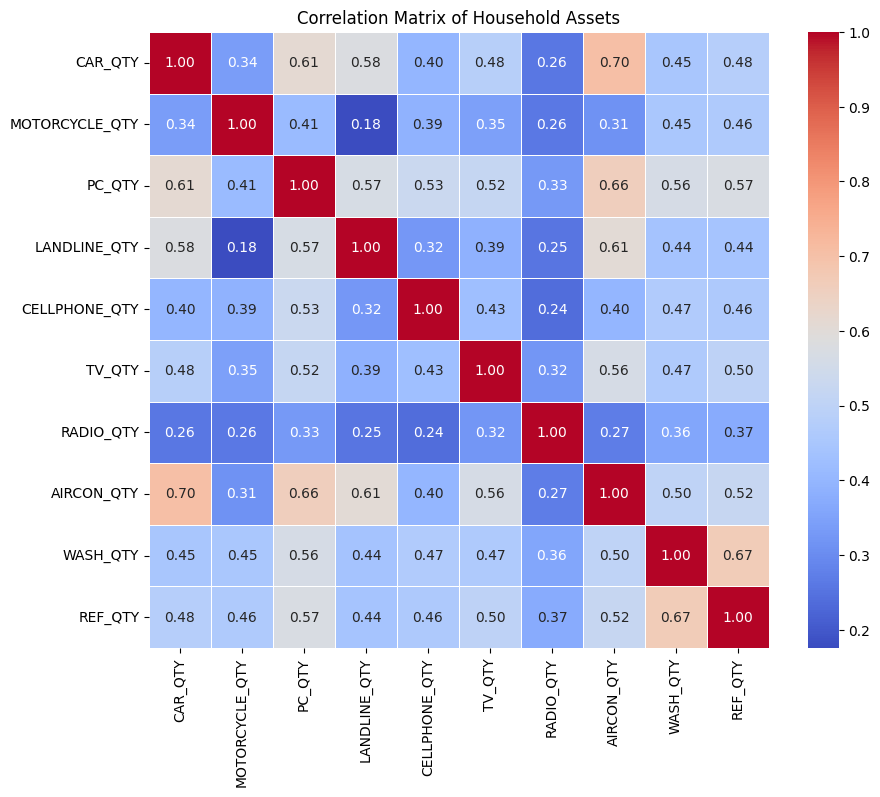

In [21]:
# C. Asset Correlation Heatmap 
# To see if owning certain items correlates with owning others
plt.figure(figsize=(10, 8))

# Coercing errors to NaN due to non-numeric entries (should we move this earlier?)
df_assets_numeric = ws_or_na_df[asset_features].apply(pd.to_numeric, errors='coerce')

correlation_matrix = df_assets_numeric.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Household Assets')
plt.show()

# **[3]** Data Preprocessing
sample text here

# **[4]** Model Selection Training


## Classical machine learning model #1

## Classical machine learning model #2

## Classical machine learning model #3

## Neural Network model #1


## Neural Network model #2

# **[5]** Error Analysis and Model Tuning
sample text here

# **[6]** Model Evaluation
sample text here

<hr/>

# AI Declaration
Chavez, Allen Visagar
- sample text

Llanes, Andre Gabriel De Ocampo
- sample text

Rojo, Von Matthew De Guzman *(leader)*
- Uses Google-search that has AI features in synthesizing different sources relevant to questions I asked.
- Uses Google Gemini to ask ways on how to import CSV dataset and scaffolding ideas for EDA

Tan, Jeremy James Teves
- sample text